<a href="https://colab.research.google.com/github/HooroBoy/PCVK_ganjil_2026/blob/dev/PCVKP1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# D2

In [ ]:
# Mengimpor seluruh library yang dibutuhkan untuk pemrosesan citra
import numpy as np
import pandas as pd
import cv2 as cv
from google.colab.patches import cv2_imshow  # Khusus Google Colab untuk menampilkan citra
from skimage import io
from skimage import transform
from PIL import Image
import matplotlib.pylab as plt

print("Semua library berhasil diimpor!")

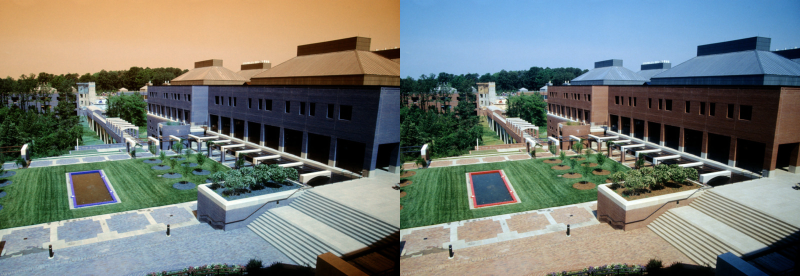

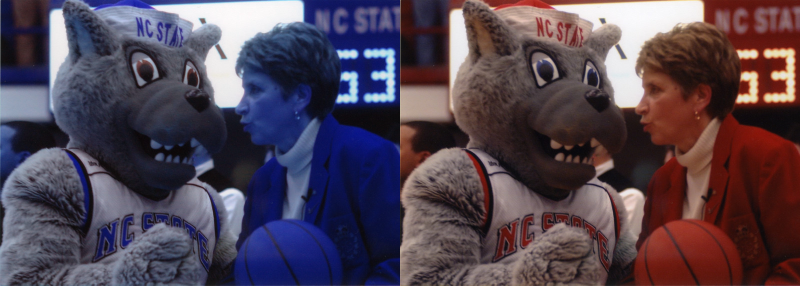

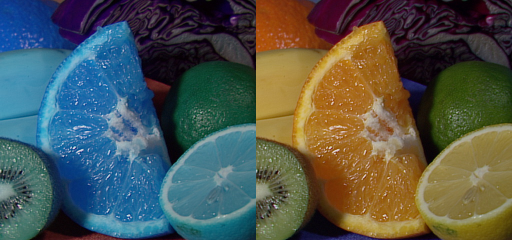

In [7]:
# List URL gambar
urls = [
    "https://iiif.lib.ncsu.edu/iiif/0052574/full/800,/0/default.jpg",
    "https://iiif.lib.ncsu.edu/iiif/0016007/full/800,/0/default.jpg",
    "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/fruits.jpg"
]

# Loop membaca, me-resize, konversi warna, dan menampilkan citra
for url in urls:
    # Membaca gambar dari URL (format default skimage adalah RGB)
    image = io.imread(url)

    # Resize ukuran citra menjadi 50% (setengahnya)
    image = cv.resize(image, (0, 0), fx=0.5, fy=0.5)

    # Konversi channel warna dari BGR ke RGB untuk melihat efek perbedaannya
    image_2 = cv.cvtColor(image, cv.COLOR_BGR2RGB)

    # Menggabungkan gambar asli dan gambar konversi secara horizontal
    final_frame = cv.hconcat((image, image_2))

    # Tampilkan gambar
    cv2_imshow(final_frame)
    print('\n')

resolusi image: tinggi x lebar = 240 x 256


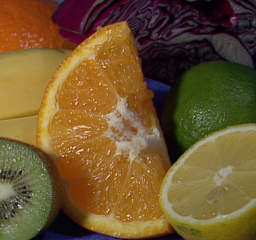

In [8]:
# Mengambil dimensi tinggi dan lebar dari citra terakhir
tinggi = image_2.shape[0]
lebar = image_2.shape[1]

print("resolusi image: tinggi x lebar =", tinggi, "x", lebar)
cv2_imshow(image_2)

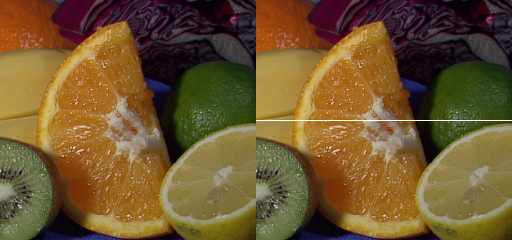

In [9]:
# Mempersiapkan citra untuk dimodifikasi
image_2 = cv.cvtColor(image, cv.COLOR_BGR2RGB)
image_3 = cv.cvtColor(image, cv.COLOR_BGR2RGB)

# Memberi garis horizontal putih di tengah gambar
# Koordinat sumbu Y (baris) dikunci di tengah: int(tinggi / 2)
# Nilai [255, 255, 255] adalah warna putih murni
for y in range(lebar):
    image_3[int(tinggi / 2), y] = [255, 255, 255]

# Tampilkan citra sebelum vs sesudah diberi garis
final_frame = cv.hconcat((image_2, image_3))
cv2_imshow(final_frame)

Hasil Tugas 1: Garis Vertikal & Garis Diagonal Menyilang


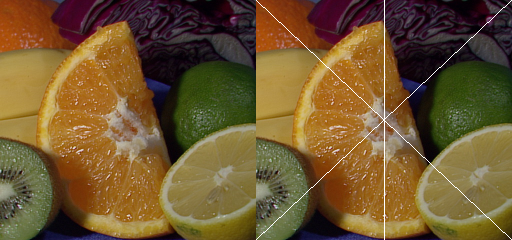



Hasil Tugas 2: Garis Horizontal dengan Panjang Tertentu


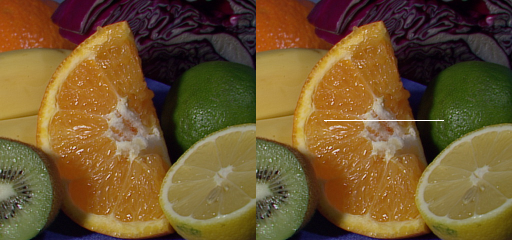



Hasil Tugas 3: Kotak Berisi Kumpulan Piksel Putih


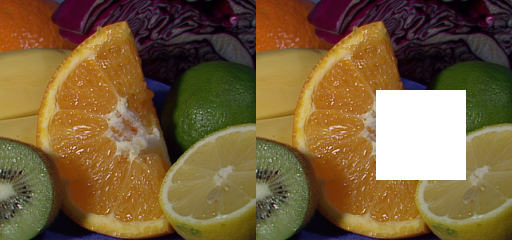

In [10]:
# =======================================================
# TUGAS PRAKTIKUM D2
# =======================================================

# Siapkan kanvas awal (citra RGB)
base_img = cv.cvtColor(image, cv.COLOR_BGR2RGB)
h, w = base_img.shape[:2]

# -------------------------------------------------------
# SOAL 1: Garis Vertikal & Garis Menyilang Diagonal
# -------------------------------------------------------
img_tugas1 = base_img.copy()

# A. Garis Vertikal di tengah (dari atas ke bawah)
for x in range(h):
    img_tugas1[x, int(w / 2)] = [255, 255, 255]

# B. Garis Diagonal Silang Menyilang (Membentuk huruf 'X')
# Diagonal 1: dari kiri-atas (0, 0) ke kanan-bawah (w-1, h-1)
cv.line(img_tugas1, (0, 0), (w - 1, h - 1), (255, 255, 255), thickness=1)

# Diagonal 2: dari kiri-bawah (0, h-1) ke kanan-atas (w-1, 0)
cv.line(img_tugas1, (0, h - 1), (w - 1, 0), (255, 255, 255), thickness=1)

print("Hasil Tugas 1: Garis Vertikal & Garis Diagonal Menyilang")
cv2_imshow(cv.hconcat([base_img, img_tugas1]))
print('\n')

# -------------------------------------------------------
# SOAL 2: Garis Horizontal di Bagian Tengah dengan Panjang Tertentu
# -------------------------------------------------------
img_tugas2 = base_img.copy()

# Tentukan batas panjang garis (misalnya panjang total 120 piksel di tengah)
panjang_garis = 120
titik_mulai_x = int(w / 2) - int(panjang_garis / 2)
titik_akhir_x = int(w / 2) + int(panjang_garis / 2)
posisi_y = int(h / 2)

# Mengisi piksel hanya pada rentang titik_mulai sampai titik_akhir
for y in range(titik_mulai_x, titik_akhir_x):
    img_tugas2[posisi_y, y] = [255, 255, 255]

print("Hasil Tugas 2: Garis Horizontal dengan Panjang Tertentu")
cv2_imshow(cv.hconcat([base_img, img_tugas2]))
print('\n')

# -------------------------------------------------------
# SOAL 3: Kotak Putih Menggunakan Kumpulan Piksel
# -------------------------------------------------------
img_tugas3 = base_img.copy()

# Cara 1: Menggunakan array slicing NumPy (baris y1:y2, kolom x1:x2)
# Misal kotak berukuran 90x90 piksel di area hidung/mata kucing
y1, y2 = 90, 180
x1, x2 = 120, 210
img_tugas3[y1:y2, x1:x2] = [255, 255, 255]

print("Hasil Tugas 3: Kotak Berisi Kumpulan Piksel Putih")
cv2_imshow(cv.hconcat([base_img, img_tugas3]))

# Jawaban Pertanyaan Praktikum D2

1. Mengapa praktikum dieksekusi di Google Colab?
      Karena berjalan berbasis cloud, siap pakai tanpa repot melakukan konfigurasi environment lokal, mendukung kolaborasi langsung via Google Drive/GitHub, serta menyediakan resource komputasi gratis.
2. Kegunaan library pada langkah 1 & apakah wajib digunakan semua?numpy untuk manipulasi array matriks citra, cv2 untuk pemrosesan visi komputer skimage.io untuk download/baca URL citra, cv2_imshow untuk menampilkan citra di web browser Colabmatplotlib untuk visualisasi berkoordinat
Apakah semua wajib
  Tidak. Library seperti pandas dan skimage.transform tidak terpakai langsung pada operasi dasar manipulasi piksel ini.
4. Kegunaan image = cv.resize(image, (0,0), fx=0.5, fy=0.5):
      Berfungsi mengecilkan dimensi citra sebesar 50% (skala 0.5) pada sumbu horizontal dan vertikal. Jika tidak dilakukan, ukuran gambar tetap besar, memakan memori komputasi lebih tinggi, dan tampilan preview gambar di layar notebook akan terlalu besar.
5. Kegunaan kode [255, 255, 255]:
      Menyatakan nilai warna maksimum untuk kombinasi 3 kanal [Red, Green, Blue] dengan kedalaman bit 8-bit. Gabungan nilai maksimal ini menghasilkan warna putih.  Keterkaitan pixel dan resolusi gambar:Resolusi gambar ditentukan oleh total perkalian pixel horizontal dan vertikal ($W \times H$). Resolusi tinggi memiliki kerapatan pixel yang padat sehingga gambar tetap tajam ketika diperbesar, sedangkan resolusi rendah membuat gambar terlihat buram atau pecah (kotak-kotak).  